In [ ]:
pip install numpy pandas scikit-learn nltk wordcloud gensim

In [213]:
# Import necessary libraries
import os
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import gensim.downloader as api
import numpy as np

In [214]:
glove_model = api.load('glove-twitter-200')  # 200-dimensional vectors

In [215]:
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [216]:
df = pd.read_csv('raw_dataset.csv')

In [217]:
df

,text,label
0,The psychiatrist diagnosed me with depression ...,depression
1,Loss of libido with no medication. Occasional ...,depression
2,"intense, mind-boggling mood swings?\nhey team....",depression
3,I've been diagnosed with severe depression and...,depression
4,diagnosed with MDD and then diagnosed with Bip...,depression
...,...,...
984,Economy class flights need regulations to esta...,control
985,What is the role of playing in adulthood?\nI f...,control
986,My brother save me from getting bullied\nSo my...,control
987,Do you guys ever just tear up at the thought o...,control


In [218]:
print(df.loc[20]["text"])

I can't clean my room

I'm NB (18) and I am diagnosed with anxiety, depression and BPD. It's been months since I've cleaned my room and it's in the worst state it's ever been in. There is no rotting food but there are empty pop cans and bottles along with piles of clothes, some paper and other random junk on the floor. But the worse it gets I feel even more demotivated to do anything so it's like my depression is making my depression worse. My partner is also living with me but we both deal with similar diagnosis which doesn't make it easier.

Any advice on what I can do to clean my room? I'm really embarrassed of it and I'm tired of seeing it in the state that it is in. Obviously cleaning my room is the solution but more specifically how can I motivate myself to finish it or what can I do to make it easier.  I tend to get bored and distracted while cleaning which is another thing that can make it hard for me.

Edit: I forgot to mention there have been days recently where I've missed m

Dataset Statistics:

Number of texts in each class:
control       698
depression    291
Name: label, dtype: int64

Average number of words per text:
label
control       131.267908
depression    219.518900
Name: num_words, dtype: float64


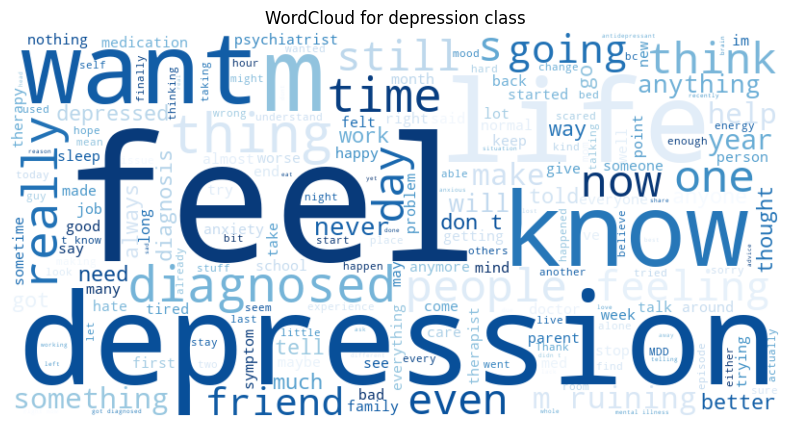

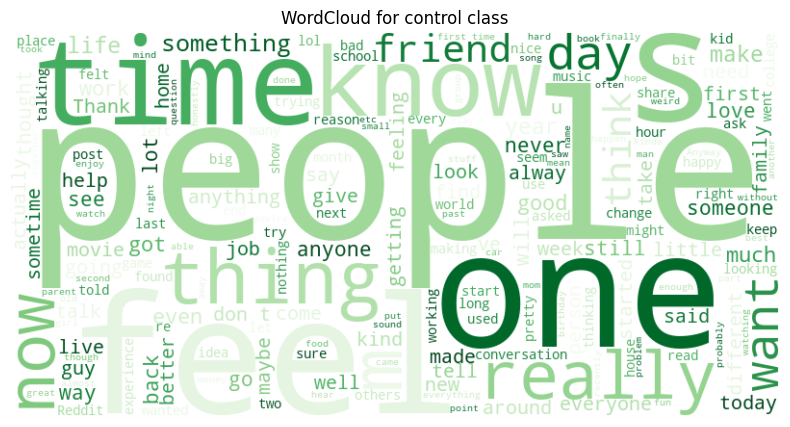

In [219]:
# Dataset statistics
print("Dataset Statistics:")

# Number of texts per class
class_counts = df['label'].value_counts()
print("\nNumber of texts in each class:")
print(class_counts)

# Number of words per text
df['num_words'] = df['text'].apply(lambda x: len(x.split()))
print("\nAverage number of words per text:")
print(df.groupby('label')['num_words'].mean())

# Generate WordClouds
for label, colormap in zip(df['label'].unique(), ["Blues", "Greens"]):
    text = ' '.join(df[df['label'] == label]['text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=colormap).generate(text)
    
    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud for {label} class')
    plt.show()


In [220]:
# 2. Preprocess text data

# Download necessary resources for preprocessing
nltk.download('stopwords')
nltk.download('wordnet')

# Combine all text to calculate global word frequencies
all_text = ' '.join(df['text'])
word_counts = Counter(all_text.split())

# Define thresholds for filtering words
min_appearance = 3  # Minimum global frequency

total_texts = len(df)

# Filter words to keep
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
words_to_keep = {word for word, count in word_counts.items() if count >= min_appearance}

# Preprocess each text
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # Keep only letters and spaces
    words = text.lower().split()  # Lowercase and split into words
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words]  # Lemmatize
    words = [word for word in words if word in words_to_keep]  # Keep only valid words
    return ' '.join(words)

# Apply preprocessing and save
df['preprocessed_text'] = df['text'].apply(preprocess_text)
df[['preprocessed_text', 'label']].to_csv('preprocessed_dataset.csv', index=False)
print("Preprocessed dataset saved as preprocessed_dataset.csv")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\madha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\madha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessed dataset saved as preprocessed_dataset.csv


In [221]:
print(df.loc[20]["preprocessed_text"])

clean room diagnosed anxiety depression month since cleaned room worst state ever food empty pop can bottle along clothes paper random junk floor worse get feel even anything like depression making depression worse partner also living deal similar diagnosis make easier advice clean room really embarrassed tired seeing state obviously cleaning room solution specifically motivate finish make easier tend get bored distracted cleaning another thing make hard forgot mention day recently missed medication may making depression worse sure


In [222]:
# Number of words per text
df['num_words'] = df['preprocessed_text'].apply(lambda x: len(x.split()))
print("\nAverage number of words per text:")
print(df.groupby('label')['num_words'].mean())


Average number of words per text:
label
control       51.164756
depression    88.158076
Name: num_words, dtype: float64


In [223]:
# 3. Extract TF-IDF features
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df['preprocessed_text'])
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df['label'] = df['label']
tfidf_df.to_csv('tfidf_features.csv', index=False)
print("TF-IDF features saved as tfidf_features.csv")

TF-IDF features saved as tfidf_features.csv


In [224]:
tfidf_df.shape

(989, 2457)

In [226]:
# 4. Train and Test RF Classifier
X = tfidf_df.drop(columns=['label'])
y = tfidf_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [227]:
# Train RF model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [228]:
# Predict and evaluate on test set
y_pred = rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

     control       0.92      0.99      0.95       213
  depression       0.97      0.77      0.86        84

    accuracy                           0.93       297
   macro avg       0.94      0.88      0.91       297
weighted avg       0.93      0.93      0.93       297



In [229]:
example_row = 20
example_tfidf = tfidf_df.drop(columns=['label']).iloc[example_row].values.reshape(1, -1)

print(df.loc[example_row]["text"])
rf.predict(example_tfidf)[0]

I can't clean my room

I'm NB (18) and I am diagnosed with anxiety, depression and BPD. It's been months since I've cleaned my room and it's in the worst state it's ever been in. There is no rotting food but there are empty pop cans and bottles along with piles of clothes, some paper and other random junk on the floor. But the worse it gets I feel even more demotivated to do anything so it's like my depression is making my depression worse. My partner is also living with me but we both deal with similar diagnosis which doesn't make it easier.

Any advice on what I can do to clean my room? I'm really embarrassed of it and I'm tired of seeing it in the state that it is in. Obviously cleaning my room is the solution but more specifically how can I motivate myself to finish it or what can I do to make it easier.  I tend to get bored and distracted while cleaning which is another thing that can make it hard for me.

Edit: I forgot to mention there have been days recently where I've missed m

'depression'

In [ ]:
# 5. Load GloVe embeddings (e.g., GloVe Twitter 200d)
glove_model = api.load('glove-twitter-200')  # 200-dimensional vectors

In [230]:
# Function to get the average GloVe embedding for a text
def get_glove_embedding(text, model):
    words = text.split()
    word_vectors = []
    
    for word in words:
        if word in model.key_to_index:  # Check if the word exists in the model's vocabulary
            word_vectors.append(model[word])
    
    if word_vectors:
        return np.mean(word_vectors, axis=0)  # Return the mean of the word vectors
    else:
        return np.zeros(model.vector_size)  # Return a zero vector if no word in text is found in GloVe

In [231]:
from sklearn.metrics.pairwise import cosine_similarity

# Words to compare
words = ["depression", "happy", "sad"]

# Get the GloVe embeddings for these words
embeddings = np.array([get_glove_embedding(word, glove_model) for word in words])

# Compute the cosine similarity between 'depression' and the other words
similarity_happy = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
similarity_sad = cosine_similarity([embeddings[0]], [embeddings[2]])[0][0]

# Print similarity percentages
print(f"Similarity between 'depression' and 'happy': {similarity_happy * 100:.2f}%")
print(f"Similarity between 'depression' and 'sad': {similarity_sad * 100:.2f}%")

Similarity between 'depression' and 'happy': 22.62%
Similarity between 'depression' and 'sad': 39.95%


In [232]:
# Create embeddings for each preprocessed text
glove_embeddings = np.array([get_glove_embedding(text, glove_model) for text in df['preprocessed_text']])

# Convert to DataFrame and save as CSV
glove_df = pd.DataFrame(glove_embeddings)
glove_df['label'] = df['label']
glove_df.to_csv('glove_embeddings.csv', index=False)
print("GloVe embeddings saved as glove_embeddings.csv")

GloVe embeddings saved as glove_embeddings.csv


In [233]:
# 6. Train and Test Random Forest Classifier with GloVe Features (70-30 train-test split)
X_glove = glove_df.drop(columns=['label'])
y_glove = glove_df['label']
X_train, X_test, y_train, y_test = train_test_split(X_glove, y_glove, test_size=0.3, random_state=42)

In [234]:
# Train Random Forest model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [235]:
# Predict and evaluate on the test set
y_pred_glove = rf.predict(X_test)
print("Classification Report (GloVe):\n", classification_report(y_test, y_pred_glove))

Classification Report (GloVe):
               precision    recall  f1-score   support

     control       0.90      0.98      0.94       213
  depression       0.93      0.74      0.82        84

    accuracy                           0.91       297
   macro avg       0.91      0.86      0.88       297
weighted avg       0.91      0.91      0.91       297



In [237]:
example_row = 700
example_glove = glove_df.drop(columns=['label']).iloc[example_row].values.reshape(1, -1)

print(df.loc[example_row]["text"])
rf.predict(example_glove)[0]

How did you all spend the weekend?
The weekend is here and I'm feeling a little bored and looking for someone to talk to. If you feel the same way, why don't you come along and have a chat! We can talk about life, our hobbies, or share some interesting stories and experiences. Sometimes, a simple chat can make us feel more pleasant and relaxed. If you're looking for someone to chat with too, feel free to private message me and we'll have a great weekend together!


'control'